In [1]:
import numpy as np

def build_Q(costs, edges, nodes, targets, P1=20, P2=20, P3=20):
    source = [k for k, v in targets.items() if v == 1][0]
    sink   = [k for k, v in targets.items() if v == -1][0]

    intermediate_nodes = [v for v in nodes if v not in [source, sink]]

    num_helpers = len(intermediate_nodes)
    num_vars = len(costs) + num_helpers

    Q = np.zeros((num_vars, num_vars))
    

    # Add linear edge costs
    for i in range(len(costs)):
        Q[i, i] += costs[i]

    # Flow conservation constraints (P1)
    for v in nodes:
        conn = []

        for i, (u, w) in enumerate(edges):
            if u == v:
                conn.append((i, 1))      # outgoing
            elif w == v:
                conn.append((i, -1))     # incoming

        Tv = targets[v]

        for i, s_vi in conn:
            Q[i, i] += P1 * (1 - 2 * Tv * s_vi)

            for j, s_vj in conn:
                if i < j:
                    Q[i, j] += 2 * P1 * s_vi * s_vj

    # Degree constraints for intermediate nodes (P2)
    for offset, v in enumerate(intermediate_nodes):
        y_idx = len(costs) + offset

        conn = []
        for i, (u, w) in enumerate(edges):
            if u == v or w == v:
                conn.append(i)

        # edge-edge terms
        for i in conn:
            Q[i, i] += P2
            for j in conn:
                if i < j:
                    Q[i, j] += 2 * P2

        # edge-helper interaction
        for i in conn:
            Q[i, y_idx] -= 4 * P2

        # helper diagonal
        Q[y_idx, y_idx] += 4 * P2

    # Endpoint constraints (P3)

    # Source node A = node 0, exactly one outgoing edge
    edges_from_source = [i for i, (u, w) in enumerate(edges) if u == source]

    
    
    for i in edges_from_source:
        Q[i, i] += P3
        for j in edges_from_source:
            if i < j:
                Q[i, j] += 2 * P3
        Q[i, i] -= 2 * P3


    # Sink node D = node 3, exactly one incoming edge
    edges_to_sink = [i for i, (u, w) in enumerate(edges) if w == sink]

    for i in edges_to_sink:
        Q[i, i] += P3
        for j in edges_to_sink:
            if i < j:
                Q[i, j] += 2 * P3
        Q[i, i] -= 2 * P3

    return Q

In [2]:
edges = [
    (0,1),
    (0,2),
    (1,2),
    (1,3),
    (2,3),
    (2,4),
    (3,4)
]

edge_names = ["01","02","12","13","23","24","34"]

costs = [2,4,1,3,2,5,1]

nodes = [0,1,2,3,4]

targets = {
    0: 1,   # source
    4: -1,  # sink
    1: 0,
    2: 0,
    3: 0
}

Q = build_Q(costs, edges, nodes, targets)
print(Q.shape)
print(Q)

(10, 10)
[[  2.  80.   0.   0.   0.   0.   0. -80.   0.   0.]
 [  0.   4.  80.   0.   0.   0.   0.   0. -80.   0.]
 [  0.   0.  81.  80.   0.   0.   0. -80. -80.   0.]
 [  0.   0.   0.  83.  80.   0.   0. -80.   0. -80.]
 [  0.   0.   0.   0.  82.  80.   0.   0. -80. -80.]
 [  0.   0.   0.   0.   0.   5.  80.   0. -80.   0.]
 [  0.   0.   0.   0.   0.   0.   1.   0.   0. -80.]
 [  0.   0.   0.   0.   0.   0.   0.  80.   0.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.  80.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   0.  80.]]


In [3]:
from qat.opt import QUBO
# Build QUBO for SQA
Q = build_Q(costs, edges, nodes, targets)
# Make Q symmetric
Q = (Q + Q.T) / 2

print("Q matrix:")
print(Q)

Q matrix:
[[  2.  40.   0.   0.   0.   0.   0. -40.   0.   0.]
 [ 40.   4.  40.   0.   0.   0.   0.   0. -40.   0.]
 [  0.  40.  81.  40.   0.   0.   0. -40. -40.   0.]
 [  0.   0.  40.  83.  40.   0.   0. -40.   0. -40.]
 [  0.   0.   0.  40.  82.  40.   0.   0. -40. -40.]
 [  0.   0.   0.   0.  40.   5.  40.   0. -40.   0.]
 [  0.   0.   0.   0.   0.  40.   1.   0.   0. -40.]
 [-40.   0. -40. -40.   0.   0.   0.  80.   0.   0.]
 [  0. -40. -40.   0. -40. -40.   0.   0.  80.   0.]
 [  0.   0.   0. -40. -40.   0. -40.   0.   0.  80.]]


In [4]:
import numpy as np
from qat.qpus import SimulatedAnnealing
from qat.core import Variable
from collections import defaultdict

qubo = QUBO(Q)
# convert qubo to Ising model
ising = qubo.to_ising()
#create job for sqa
job = ising.sqa_job(nbshots=1000)

# Temperature schedule
t = Variable("t", float)
temp_t = 50* (1 - t) + 5

# Initialize SQA Solver
qpu = SimulatedAnnealing(temp_t=temp_t, n_steps=300)

result = qpu.submit(job)
print(result)

all_states = []
all_energies = []

# collect all samples
all_samples = []

for _ in range(10):   # run multiple times
    result = qpu.submit(job)

    for sample in result.raw_data:
        bitstring = ''.join(str(int(b)) for b in sample.state)
        bitstring = bitstring.zfill(Q.shape[0])

        x = np.array([int(b) for b in bitstring])
        energy = x @ Q @ x

        all_states.append(bitstring)
        all_energies.append(energy)

        all_samples.append(sample)

unique_states = set()

for sample in all_samples:

    # Convert state to bitstring
    bitstring = ''.join(str(int(b)) for b in sample.state)
    bitstring = bitstring.zfill(Q.shape[0])
    unique_states.add(bitstring)

print("Unique solutions:", len(unique_states))

# Extract solution
best_sample = None
best_energy = float('inf')


for sample in all_samples:
    bitstring = ''.join(str(int(b)) for b in sample.state)
    bitstring = bitstring.zfill(Q.shape[0])

    x = np.array([int(b) for b in bitstring])
    energy = x @ Q @ x

    if energy < best_energy:
        
        best_energy = energy
        best_sample = sample
        best_bitstring = bitstring

print("Best state:", best_bitstring)
print("Min energy:", best_energy)


# Decode edges
num_edges = len(edges)
edge_bits = best_bitstring[:num_edges]
selected_edges = [edges[i] for i, b in enumerate(edge_bits) if b == '1']
print("Selected edges:", selected_edges)

# Check valid path
def is_valid_path(selected_edges, source, sink):
    if not selected_edges:
        return False

    adj = defaultdict(list)
    for u, v in selected_edges:
        adj[u].append(v)

    current = source
    visited = set()

    while current in adj:
        if current in visited:
            return False
        visited.add(current)

        if len(adj[current]) != 1:
            return False

        current = adj[current][0]
        if current == sink:
            return True

    return False

source = [k for k, v in targets.items() if v == 1][0]
sink = [k for k, v in targets.items() if v == -1][0]

print("Valid path" if is_valid_path(selected_edges, source, sink) else "Invalid path")

Result(need_flip=False, lsb_first=False, nbqbits=None, has_statevector=False, statevector=None, data=None, _value=None, raw_data=[Sample(_amplitude=None, probability=1.0, _state=b'\x07', err=0.0, intermediate_measurements=None, qregs=[QRegister(scope=None, length=10, start=0, msb=None, _subtype_metadata=None, qbits=[<qat.lang.AQASM.bits.Qbit object at 0x1370b07d0>, <qat.lang.AQASM.bits.Qbit object at 0x1370f4550>, <qat.lang.AQASM.bits.Qbit object at 0x1370f4490>, <qat.lang.AQASM.bits.Qbit object at 0x1370f44d0>, <qat.lang.AQASM.bits.Qbit object at 0x1370f4590>, <qat.lang.AQASM.bits.Qbit object at 0x1370f4610>, <qat.lang.AQASM.bits.Qbit object at 0x1370f4650>, <qat.lang.AQASM.bits.Qbit object at 0x1370f4690>, <qat.lang.AQASM.bits.Qbit object at 0x1370f46d0>, <qat.lang.AQASM.bits.Qbit object at 0x1370f45d0>])])], qregs=[QRegister(scope=None, length=10, start=0, msb=None, _subtype_metadata=None, qbits=[<qat.lang.AQASM.bits.Qbit object at 0x1370b07d0>, <qat.lang.AQASM.bits.Qbit object at 0

/var/folders/g2/ft9y1q7d7gzcj5wjy5z9759m0000gn/T/ipykernel_10819/3755875201.py:10: UserWarning: If SQAQPU is used, gamma_t will be needed.
  job = ising.sqa_job(nbshots=1000)



Unique solutions: 3
Best state: 0000001111
Min energy: 161.0
Selected edges: [(3, 4)]
Invalid path


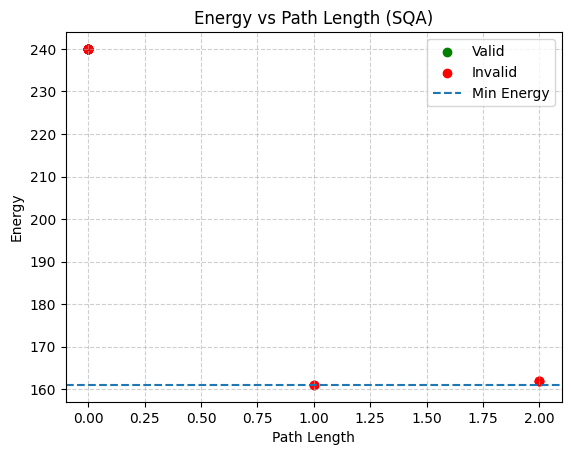

In [5]:
import matplotlib.pyplot as plt

energies = []
path_lengths = []
valid_flags = []

num_edges = len(edges)

for sample in all_samples:
    
    # Convert state → bitstring (safe for your version)
    bitstring = ''.join(str(int(b)) for b in sample.state)
    bitstring = bitstring.zfill(Q.shape[0])

    # Extract edges
    edge_bits = bitstring[:num_edges]
    selected_edges = [edges[i] for i, b in enumerate(edge_bits) if b == '1']

    # Path length
    path_length = sum(costs[i] for i, b in enumerate(edge_bits) if b == '1')

    # Validity
    valid = is_valid_path(selected_edges, source, sink)

    # Energy
    x = np.array([int(b) for b in bitstring])
    energy = x @ Q @ x

    energies.append(energy)
    path_lengths.append(path_length)
    valid_flags.append(valid)

# Valid solutions 
valid_x = [path_lengths[i] for i in range(len(energies)) if valid_flags[i]]
valid_y = [energies[i] for i in range(len(energies)) if valid_flags[i]]

# Invalid solutions 
invalid_x = [path_lengths[i] for i in range(len(energies)) if not valid_flags[i]]
invalid_y = [energies[i] for i in range(len(energies)) if not valid_flags[i]]

# Plot valid and invalid solutions
plt.scatter(valid_x, valid_y, color='green', label='Valid')
plt.scatter(invalid_x, invalid_y, color='red', label='Invalid')

plt.xlabel("Path Length")
plt.ylabel("Energy")
plt.title("Energy vs Path Length (SQA)")

plt.axhline(y=min(energies), linestyle='--', label='Min Energy')


plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

In [6]:
# Create a QAOA job with 2 layers
job = ising.qaoa_job(2, False)

In [7]:
from qat.qpus import get_default_qpu
#Initialize QPU
qpu = get_default_qpu()

result = qpu.submit(job)

print(result)
print("Optimal parameters:", result.parameter_map)

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Result(need_flip=False, lsb_first=False, nbqbits=None, has_statevector=False, statevector=None, data=None, _value=ComplexNumber(re=-560.6594683256651, im=0.0), raw_data=None, qregs=[QRegister(scope=<qat.lang.AQASM.program.Program object at 0x124b90810>, length=10, start=0, msb=None, _subtype_metadata=None, qbits=[<qat.lang.AQASM.bits.Qbit object at 0x1370b5fd0>, <qat.lang.AQASM.bits.Qbit object at 0x1378ee990>, <qat.lang.AQASM.bits.Qbit object at 0x108787110>, <qat.lang.AQASM.bits.Qbit object at 0x13703f8d0>, <qat.lang.AQASM.bits.Qbit object at 0x13701f610>, <qat.lang.AQASM.bits.Qbit object at 0x136e45010>, <qat.lang.AQASM.bits.Qbit object at 0x136b6cb90>, <qat.lang.AQASM.bits.Qbit object at 0x1370f4190>, <qat.lang.AQASM.bits.Qbit object at 0x1370f47d0>, <qat.lang.AQASM.bits.Qbit object at 0x136e44f90>])], error=None, value_data=None, error_data=None, meta_data={'optimizer_data': '  message: Desired error not necessarily achieved due to precision loss.\n  success: False\n   status: 2\n

In [8]:
bitstrings = []
probabilities = []

# get parameters
param_map = result.parameter_map

#  bind parameters to circuit
final_job = job.circuit.bind_variables(param_map).to_job(nbshots=1000)

final_result = qpu.submit(final_job)

for sample in final_result:
    bitstring = sample.state.bitstring.zfill(Q.shape[0])  

    bitstrings.append(bitstring)
    probabilities.append(sample.probability)

print(bitstrings)
print(probabilities)

['1111111000', '1011110000', '1111100000', '1111110001', '0111111000', '1111110000', '0011111000', '0111110000', '0111110100', '1111111010', '1011111000', '1011111001', '1101001001', '0000101100', '1011110001', '0111111100', '1111101000', '0111110001', '1110100100', '0111101000', '0011111100', '1111110010', '0010011000', '0011100010', '0011100000', '1011101000', '0111111010', '0011110000', '0011100100', '1011110110', '1001110000', '1110000011', '1011100000', '0010000001', '0101100000', '0111100000', '0000101110', '0001101000', '1111100101', '0011101100', '0011001000', '0001111110', '0111100001', '0101110100', '1111100111', '1111101011', '1110010101', '1111000001', '1010000011', '1111111001', '0010000011', '1100110100', '1000001010', '1110000111', '0001101010', '1111100001', '1110000010', '0111101001', '0011100011', '0100111101', '0100000101', '0011110100', '1111111100', '1011100010', '1011111100', '0111101100', '0001001110', '1110111000', '0001000011', '1111010000', '1011100100', '1000

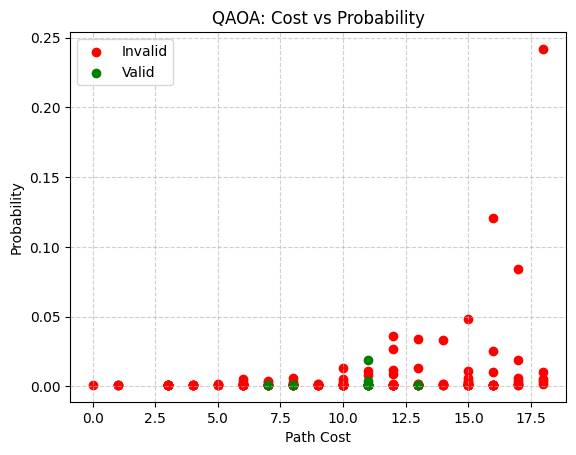

In [9]:
import matplotlib.pyplot as plt

costs_list = []
valid_flags = []

num_edges = len(edges)

for sample in final_result:

    bitstring = sample.state.bitstring.zfill(Q.shape[0])

    edge_bits = bitstring[:num_edges]
    selected_edges = [edges[i] for i, b in enumerate(edge_bits) if b == '1']

    path_cost = sum(costs[i] for i, b in enumerate(edge_bits) if b == '1')

    valid = is_valid_path(selected_edges, source, sink)

    costs_list.append(path_cost)
    valid_flags.append(valid)

# valid
valid_x = [c for c, v in zip(costs_list, valid_flags) if v]
valid_y = [p for p, v in zip(probabilities, valid_flags) if v]

# invalid
invalid_x = [c for c, v in zip(costs_list, valid_flags) if not v]
invalid_y = [p for p, v in zip(probabilities, valid_flags) if not v]

# Plot
plt.scatter(invalid_x, invalid_y, color='red', label='Invalid')
plt.scatter(valid_x, valid_y, color='green', label='Valid')

plt.xlabel("Path Cost")
plt.ylabel("Probability")
plt.title("QAOA: Cost vs Probability")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()